In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("javaidahmadwani/lc25000")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/javaidahmadwani/lc25000


In [2]:
import os
from pathlib import Path
from collections import Counter

# Dataset directory
dataset_path = Path("/kaggle/input/datasets/javaidahmadwani/lc25000/lung_colon_image_set/Train and Validation Set")

# Supported image extensions
image_extensions = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp", ".gif"
}

# Check whether the dataset path exists
if not dataset_path.exists():
    raise FileNotFoundError(f"Dataset path not found: {dataset_path}")

print(f"Dataset path: {dataset_path}")
print("=" * 80)

# Show directory structure and image count for every folder
total_images = 0
folder_results = []

for root, dirs, files in os.walk(dataset_path):
    root_path = Path(root)

    image_files = [
        file for file in files
        if Path(file).suffix.lower() in image_extensions
    ]

    image_count = len(image_files)
    total_images += image_count

    relative_path = root_path.relative_to(dataset_path)
    display_path = str(relative_path) if str(relative_path) != "." else dataset_path.name

    folder_results.append((display_path, image_count, len(files), len(dirs)))

print("FOLDER STRUCTURE AND IMAGE COUNT")
print("-" * 80)

for folder, image_count, file_count, subfolder_count in folder_results:
    print(f"Folder     : {folder}")
    print(f"Subfolders : {subfolder_count}")
    print(f"All files  : {file_count}")
    print(f"Images     : {image_count}")
    print("-" * 80)

print(f"\nTotal number of images in the dataset: {total_images}")

Dataset path: /kaggle/input/datasets/javaidahmadwani/lc25000/lung_colon_image_set/Train and Validation Set
FOLDER STRUCTURE AND IMAGE COUNT
--------------------------------------------------------------------------------
Folder     : Train and Validation Set
Subfolders : 5
All files  : 0
Images     : 0
--------------------------------------------------------------------------------
Folder     : colon_aca
Subfolders : 0
All files  : 4500
Images     : 4500
--------------------------------------------------------------------------------
Folder     : lung_aca
Subfolders : 0
All files  : 4500
Images     : 4500
--------------------------------------------------------------------------------
Folder     : lung_scc
Subfolders : 0
All files  : 4501
Images     : 4501
--------------------------------------------------------------------------------
Folder     : colon_n
Subfolders : 0
All files  : 4500
Images     : 4500
--------------------------------------------------------------------------------

In [3]:
# Install once in Kaggle
!pip install -q ImageHash

import hashlib
import shutil
from collections import defaultdict
from pathlib import Path

import imagehash
import pandas as pd
from PIL import Image, ImageFile
from tqdm.auto import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = True


# ============================================================
# SETTINGS
# ============================================================

SOURCE_DIR = Path(
    "/kaggle/input/datasets/javaidahmadwani/lc25000/"
    "lung_colon_image_set/Train and Validation Set"
)

OUTPUT_DIR = Path(
    "/kaggle/working/LC25000_Deduplicated"
)

REPORT_DIR = Path(
    "/kaggle/working/LC25000_Duplicate_Reports"
)

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp"
}

# Perceptual-hash Hamming distance.
# 0 means visually identical; 4–6 is a reasonable near-duplicate range.
NEAR_DUPLICATE_THRESHOLD = 5

# True: compare near duplicates across the entire dataset.
# False: compare only within the same class folder.
COMPARE_NEAR_DUPLICATES_ACROSS_CLASSES = True

# Remove old output before creating the cleaned dataset.
RESET_OUTPUT = True


# ============================================================
# INITIALIZATION
# ============================================================

if not SOURCE_DIR.exists():
    raise FileNotFoundError(f"Dataset not found:\n{SOURCE_DIR}")

if RESET_OUTPUT:
    if OUTPUT_DIR.exists():
        shutil.rmtree(OUTPUT_DIR)

    if REPORT_DIR.exists():
        shutil.rmtree(REPORT_DIR)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

image_paths = sorted([
    path for path in SOURCE_DIR.rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
])

print("Dataset path:", SOURCE_DIR)
print("Total images found:", len(image_paths))


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def calculate_sha256(image_path, chunk_size=1024 * 1024):
    """Calculate exact file-content hash."""

    sha256 = hashlib.sha256()

    with open(image_path, "rb") as file:
        while True:
            chunk = file.read(chunk_size)

            if not chunk:
                break

            sha256.update(chunk)

    return sha256.hexdigest()


def calculate_pixel_hash(image_path):
    """
    Hash decoded RGB pixel values.

    This detects identical images saved with different JPEG
    compression levels or metadata only when decoded pixels match.
    """

    with Image.open(image_path) as image:
        image = image.convert("RGB")

        sha256 = hashlib.sha256()
        sha256.update(str(image.size).encode())
        sha256.update(image.tobytes())

        return sha256.hexdigest()


def calculate_perceptual_hash(image_path):
    """Calculate a 64-bit perceptual hash."""

    with Image.open(image_path) as image:
        image = image.convert("RGB")
        return imagehash.phash(image, hash_size=8)


def get_class_name(image_path):
    """
    Uses the immediate parent directory as the class name.

    Example:
    train/lung_aca/image.jpg -> lung_aca
    """

    return image_path.parent.name


def copy_unique_image(source_path):
    """Copy an image while preserving its relative folder structure."""

    relative_path = source_path.relative_to(SOURCE_DIR)
    destination_path = OUTPUT_DIR / relative_path

    destination_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    shutil.copy2(
        source_path,
        destination_path
    )

    return destination_path


def get_hash_chunks(hash_integer, chunks=8, bits_per_chunk=8):
    """
    Split a 64-bit perceptual hash into 8 chunks.

    Candidate search using chunks prevents comparison of every
    image against every other image.
    """

    masks = (1 << bits_per_chunk) - 1

    return [
        (hash_integer >> (index * bits_per_chunk)) & masks
        for index in range(chunks)
    ]


# ============================================================
# DUPLICATE DETECTION
# ============================================================

exact_file_hashes = {}
exact_pixel_hashes = {}

# Each bucket stores retained image indices that share one pHash chunk.
phash_buckets = defaultdict(list)

retained_images = []
duplicate_records = []
corrupted_records = []

counts = {
    "total": len(image_paths),
    "unique": 0,
    "exact_file_duplicates": 0,
    "exact_pixel_duplicates": 0,
    "near_duplicates": 0,
    "corrupted": 0
}


for image_path in tqdm(
    image_paths,
    desc="Finding and removing duplicates"
):
    relative_path = image_path.relative_to(SOURCE_DIR)
    class_name = get_class_name(image_path)

    try:
        # ----------------------------------------------------
        # 1. Exact duplicate by file bytes
        # ----------------------------------------------------

        file_hash = calculate_sha256(image_path)

        if file_hash in exact_file_hashes:
            original = exact_file_hashes[file_hash]

            duplicate_records.append({
                "Duplicate File": str(relative_path),
                "Retained File": str(
                    original["path"].relative_to(SOURCE_DIR)
                ),
                "Duplicate Type": "Exact file duplicate",
                "Hash Distance": 0,
                "Duplicate Class": class_name,
                "Retained Class": original["class_name"]
            })

            counts["exact_file_duplicates"] += 1
            continue

        # ----------------------------------------------------
        # 2. Exact decoded-pixel duplicate
        # ----------------------------------------------------

        pixel_hash = calculate_pixel_hash(image_path)

        if pixel_hash in exact_pixel_hashes:
            original = exact_pixel_hashes[pixel_hash]

            duplicate_records.append({
                "Duplicate File": str(relative_path),
                "Retained File": str(
                    original["path"].relative_to(SOURCE_DIR)
                ),
                "Duplicate Type": "Exact pixel duplicate",
                "Hash Distance": 0,
                "Duplicate Class": class_name,
                "Retained Class": original["class_name"]
            })

            counts["exact_pixel_duplicates"] += 1
            continue

        # ----------------------------------------------------
        # 3. Near duplicate using perceptual hash
        # ----------------------------------------------------

        perceptual_hash = calculate_perceptual_hash(image_path)
        hash_integer = int(str(perceptual_hash), 16)

        hash_chunks = get_hash_chunks(hash_integer)

        # Get possible matches from shared hash chunks.
        candidate_indices = set()

        for chunk_position, chunk_value in enumerate(hash_chunks):
            bucket_key = (
                chunk_position,
                chunk_value
            )

            candidate_indices.update(
                phash_buckets[bucket_key]
            )

        best_match = None
        best_distance = float("inf")

        for candidate_index in candidate_indices:
            candidate = retained_images[candidate_index]

            if (
                not COMPARE_NEAR_DUPLICATES_ACROSS_CLASSES
                and candidate["class_name"] != class_name
            ):
                continue

            distance = (
                perceptual_hash -
                candidate["perceptual_hash"]
            )

            if distance < best_distance:
                best_distance = distance
                best_match = candidate

        if (
            best_match is not None
            and best_distance <= NEAR_DUPLICATE_THRESHOLD
        ):
            duplicate_records.append({
                "Duplicate File": str(relative_path),
                "Retained File": str(
                    best_match["path"].relative_to(SOURCE_DIR)
                ),
                "Duplicate Type": "Near duplicate",
                "Hash Distance": int(best_distance),
                "Duplicate Class": class_name,
                "Retained Class": best_match["class_name"]
            })

            counts["near_duplicates"] += 1
            continue

        # ----------------------------------------------------
        # 4. Retain unique image
        # ----------------------------------------------------

        output_path = copy_unique_image(image_path)

        retained_index = len(retained_images)

        retained_images.append({
            "path": image_path,
            "output_path": output_path,
            "class_name": class_name,
            "file_hash": file_hash,
            "pixel_hash": pixel_hash,
            "perceptual_hash": perceptual_hash
        })

        exact_file_hashes[file_hash] = retained_images[-1]
        exact_pixel_hashes[pixel_hash] = retained_images[-1]

        for chunk_position, chunk_value in enumerate(hash_chunks):
            bucket_key = (
                chunk_position,
                chunk_value
            )

            phash_buckets[bucket_key].append(
                retained_index
            )

        counts["unique"] += 1

    except Exception as error:
        counts["corrupted"] += 1

        corrupted_records.append({
            "File": str(relative_path),
            "Error": str(error)
        })


# ============================================================
# SAVE REPORTS
# ============================================================

duplicate_columns = [
    "Duplicate File",
    "Retained File",
    "Duplicate Type",
    "Hash Distance",
    "Duplicate Class",
    "Retained Class"
]

duplicate_df = pd.DataFrame(
    duplicate_records,
    columns=duplicate_columns
)

corrupted_df = pd.DataFrame(
    corrupted_records,
    columns=["File", "Error"]
)

duplicate_df.to_csv(
    REPORT_DIR / "duplicate_images.csv",
    index=False
)

corrupted_df.to_csv(
    REPORT_DIR / "corrupted_images.csv",
    index=False
)


# ============================================================
# CLASS-WISE COUNTS
# ============================================================

original_class_counts = defaultdict(int)
cleaned_class_counts = defaultdict(int)

for path in image_paths:
    original_class_counts[get_class_name(path)] += 1

for item in retained_images:
    cleaned_class_counts[item["class_name"]] += 1

class_rows = []

all_classes = sorted(
    set(original_class_counts) |
    set(cleaned_class_counts)
)

for class_name in all_classes:
    original_count = original_class_counts[class_name]
    cleaned_count = cleaned_class_counts[class_name]

    class_rows.append({
        "Class": class_name,
        "Original Images": original_count,
        "Cleaned Images": cleaned_count,
        "Removed Images": original_count - cleaned_count
    })

class_count_df = pd.DataFrame(class_rows)

class_count_df.to_csv(
    REPORT_DIR / "class_wise_counts.csv",
    index=False
)


# ============================================================
# CROSS-CLASS DUPLICATE REPORT
# ============================================================

if not duplicate_df.empty:
    cross_class_df = duplicate_df[
        duplicate_df["Duplicate Class"] !=
        duplicate_df["Retained Class"]
    ].copy()
else:
    cross_class_df = pd.DataFrame(
        columns=duplicate_columns
    )

cross_class_df.to_csv(
    REPORT_DIR / "cross_class_duplicates.csv",
    index=False
)


# ============================================================
# FINAL SUMMARY
# ============================================================

removed_total = (
    counts["exact_file_duplicates"]
    + counts["exact_pixel_duplicates"]
    + counts["near_duplicates"]
)

summary_df = pd.DataFrame([{
    "Original Images": counts["total"],
    "Unique Images Retained": counts["unique"],
    "Exact File Duplicates Removed":
        counts["exact_file_duplicates"],
    "Exact Pixel Duplicates Removed":
        counts["exact_pixel_duplicates"],
    "Near Duplicates Removed":
        counts["near_duplicates"],
    "Total Duplicates Removed": removed_total,
    "Corrupted Images Skipped": counts["corrupted"],
    "Cross-Class Duplicates":
        len(cross_class_df),
    "Near-Duplicate Threshold":
        NEAR_DUPLICATE_THRESHOLD
}])

summary_df.to_csv(
    REPORT_DIR / "deduplication_summary.csv",
    index=False
)

print("\n" + "=" * 70)
print("DEDUPLICATION COMPLETED")
print("=" * 70)

display(summary_df)
display(class_count_df)

print("\nCleaned dataset:")
print(OUTPUT_DIR)

print("\nReports:")
print(REPORT_DIR)

print("\nDuplicate report:")
print(REPORT_DIR / "duplicate_images.csv")

print("\nCross-class duplicate report:")
print(REPORT_DIR / "cross_class_duplicates.csv")

Dataset path: /kaggle/input/datasets/javaidahmadwani/lc25000/lung_colon_image_set/Train and Validation Set
Total images found: 22501


Finding and removing duplicates:   0%|          | 0/22501 [00:00<?, ?it/s]


DEDUPLICATION COMPLETED


,Original Images,Unique Images Retained,Exact File Duplicates Removed,Exact Pixel Duplicates Removed,Near Duplicates Removed,Total Duplicates Removed,Corrupted Images Skipped,Cross-Class Duplicates,Near-Duplicate Threshold
0,22501,20050,1010,0,1441,2451,0,0,5


,Class,Original Images,Cleaned Images,Removed Images
0,colon_aca,4500,4009,491
1,colon_n,4500,4060,440
2,lung_aca,4500,3969,531
3,lung_n,4500,3952,548
4,lung_scc,4501,4060,441



Cleaned dataset:
/kaggle/working/LC25000_Deduplicated

Reports:
/kaggle/working/LC25000_Duplicate_Reports

Duplicate report:
/kaggle/working/LC25000_Duplicate_Reports/duplicate_images.csv

Cross-class duplicate report:
/kaggle/working/LC25000_Duplicate_Reports/cross_class_duplicates.csv


In [4]:
import os
import random
import shutil

source_dir = "/kaggle/working/LC25000_Deduplicated"
output_dir = "/kaggle/working/LC25000_15Percent"

keep_ratio = 0.15
random.seed(42)

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

os.makedirs(output_dir, exist_ok=True)

for class_name in sorted(os.listdir(source_dir)):
    class_path = os.path.join(source_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(image_extensions)
    ]

    random.shuffle(images)

    keep_count = max(1, round(len(images) * keep_ratio))
    selected_images = images[:keep_count]

    output_class_path = os.path.join(output_dir, class_name)
    os.makedirs(output_class_path, exist_ok=True)

    for image_name in selected_images:
        shutil.copy2(
            os.path.join(class_path, image_name),
            os.path.join(output_class_path, image_name)
        )

    print(
        f"{class_name}: Original = {len(images)}, "
        f"Selected = {len(selected_images)}"
    )

print(f"\n15% dataset saved at: {output_dir}")

colon_aca: Original = 4009, Selected = 601
colon_n: Original = 4060, Selected = 609
lung_aca: Original = 3969, Selected = 595
lung_n: Original = 3952, Selected = 593
lung_scc: Original = 4060, Selected = 609

15% dataset saved at: /kaggle/working/LC25000_15Percent


Total images found: 3007


Preprocessing histopathology images:   0%|          | 0/3007 [00:00<?, ?it/s]


Preprocessing completed.
Images found: 3007
Images saved: 3007
Failed images: 0
Output directory: /kaggle/working/LC25000_Preprocessed1

Class folders found: 5
colon_aca
colon_n
lung_aca
lung_n
lung_scc


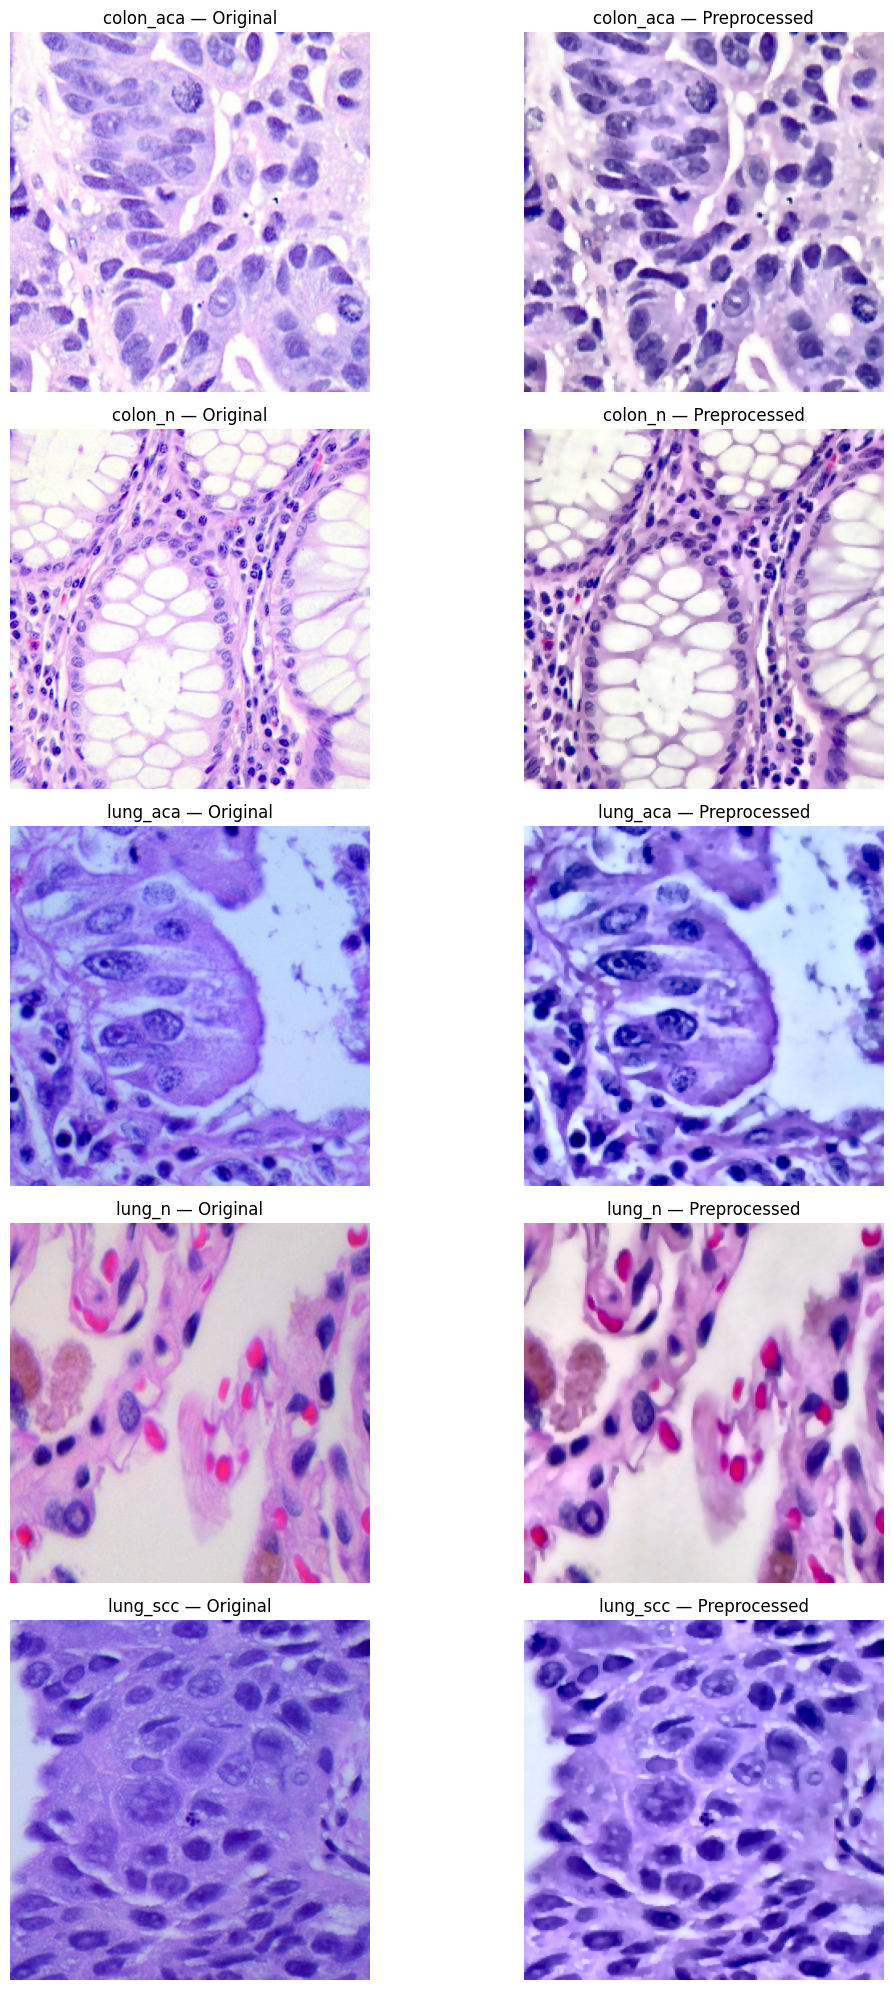

In [5]:
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.auto import tqdm


# ============================================================
# PATHS AND SETTINGS
# ============================================================

input_dir = Path("/kaggle/working/LC25000_15Percent")
output_dir = Path("/kaggle/working/LC25000_Preprocessed1")

IMG_SIZE = 224

extensions = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp"
}


# ============================================================
# HISTOPATHOLOGY PREPROCESSING
# ============================================================

def preprocess_histopathology_image(path):
    """
    Preprocessing suitable for RGB histopathology images:

    1. Read RGB tissue image
    2. Resize to 224 × 224
    3. Apply mild bilateral denoising
    4. Apply CLAHE only to luminance channel
    5. Apply mild gamma correction
    6. Preserve original stain/color information
    """

    img = cv2.imread(
        str(path),
        cv2.IMREAD_COLOR
    )

    if img is None:
        return None

    # ----------------------------------------
    # 1. Resize
    # ----------------------------------------

    img = cv2.resize(
        img,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_AREA
    )

    # ----------------------------------------
    # 2. Mild edge-preserving denoising
    # ----------------------------------------

    img = cv2.bilateralFilter(
        img,
        d=5,
        sigmaColor=25,
        sigmaSpace=25
    )

    # ----------------------------------------
    # 3. CLAHE on luminance only
    # ----------------------------------------

    lab = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2LAB
    )

    lightness, channel_a, channel_b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=1.8,
        tileGridSize=(8, 8)
    )

    enhanced_lightness = clahe.apply(
        lightness
    )

    enhanced_lab = cv2.merge([
        enhanced_lightness,
        channel_a,
        channel_b
    ])

    enhanced = cv2.cvtColor(
        enhanced_lab,
        cv2.COLOR_LAB2BGR
    )

    # ----------------------------------------
    # 4. Mild gamma correction
    # ----------------------------------------

    gamma = 1.05

    lookup_table = np.array([
        ((pixel / 255.0) ** (1.0 / gamma)) * 255
        for pixel in np.arange(256)
    ]).astype(np.uint8)

    processed = cv2.LUT(
        enhanced,
        lookup_table
    )

    return np.clip(
        processed,
        0,
        255
    ).astype(np.uint8)


# ============================================================
# FIND ALL IMAGES RECURSIVELY
# ============================================================

image_files = sorted([
    path
    for path in input_dir.rglob("*")
    if path.is_file()
    and path.suffix.lower() in extensions
])

print("Total images found:", len(image_files))


# ============================================================
# PREPROCESS AND SAVE
# ============================================================

saved_count = 0
failed_count = 0

for image_path in tqdm(
    image_files,
    desc="Preprocessing histopathology images"
):
    processed = preprocess_histopathology_image(
        image_path
    )

    if processed is None:
        failed_count += 1
        continue

    # Preserve original directory structure
    relative_path = image_path.relative_to(
        input_dir
    )

    save_path = (
        output_dir /
        relative_path.parent /
        f"{image_path.stem}.png"
    )

    save_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    success = cv2.imwrite(
        str(save_path),
        processed
    )

    if success:
        saved_count += 1
    else:
        failed_count += 1


print("\nPreprocessing completed.")
print("Images found:", len(image_files))
print("Images saved:", saved_count)
print("Failed images:", failed_count)
print("Output directory:", output_dir)


# ============================================================
# IDENTIFY CLASS FOLDERS
# ============================================================

# A class folder is treated as a folder that directly contains images.
class_folders = []

for folder in sorted([
    path
    for path in input_dir.rglob("*")
    if path.is_dir()
]):
    folder_images = [
        path
        for path in folder.iterdir()
        if path.is_file()
        and path.suffix.lower() in extensions
    ]

    if folder_images:
        class_folders.append(folder)

print("\nClass folders found:", len(class_folders))

for folder in class_folders:
    print(
        folder.relative_to(input_dir)
    )


# ============================================================
# PLOT ONE SAMPLE FROM EACH CLASS
# ============================================================

if len(class_folders) > 0:

    plt.figure(
        figsize=(12, 4 * len(class_folders))
    )

    for row, class_folder in enumerate(
        class_folders
    ):
        folder_images = [
            path
            for path in class_folder.iterdir()
            if path.is_file()
            and path.suffix.lower() in extensions
        ]

        sample_path = random.choice(
            folder_images
        )

        original = cv2.imread(
            str(sample_path)
        )

        processed = preprocess_histopathology_image(
            sample_path
        )

        original_rgb = cv2.cvtColor(
            original,
            cv2.COLOR_BGR2RGB
        )

        processed_rgb = cv2.cvtColor(
            processed,
            cv2.COLOR_BGR2RGB
        )

        class_name = str(
            class_folder.relative_to(input_dir)
        )

        # Original image
        plt.subplot(
            len(class_folders),
            2,
            row * 2 + 1
        )

        plt.imshow(original_rgb)
        plt.title(
            f"{class_name} — Original"
        )
        plt.axis("off")

        # Preprocessed image
        plt.subplot(
            len(class_folders),
            2,
            row * 2 + 2
        )

        plt.imshow(processed_rgb)
        plt.title(
            f"{class_name} — Preprocessed"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

else:
    print(
        "No class folders containing images were found."
    )

In [6]:
import os
import random
import shutil
from pathlib import Path

# Paths
source_dir = Path("/kaggle/working/LC25000_Preprocessed1")
output_dir = Path("/kaggle/working/PVMD_Split")

# Split ratios
train_ratio = 0.80
val_ratio = 0.10
test_ratio = 0.10

# Reproducibility
random.seed(42)

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

# Remove old output folder if it exists
if output_dir.exists():
    shutil.rmtree(output_dir)

for class_dir in source_dir.iterdir():
    if not class_dir.is_dir():
        continue

    images = [
        file for file in class_dir.iterdir()
        if file.is_file() and file.suffix.lower() in image_extensions
    ]

    random.shuffle(images)

    total = len(images)
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    splits = {
        "train": images[:train_end],
        "validation": images[train_end:val_end],
        "test": images[val_end:]
    }

    for split_name, split_images in splits.items():
        destination = output_dir / split_name / class_dir.name
        destination.mkdir(parents=True, exist_ok=True)

        for image_path in split_images:
            shutil.copy2(image_path, destination / image_path.name)

    print(
        f"{class_dir.name}: "
        f"Train={len(splits['train'])}, "
        f"Validation={len(splits['validation'])}, "
        f"Test={len(splits['test'])}"
    )

print(f"\nSplit dataset saved at: {output_dir}")

lung_n: Train=474, Validation=59, Test=60
lung_scc: Train=487, Validation=60, Test=62
colon_n: Train=487, Validation=60, Test=62
lung_aca: Train=476, Validation=59, Test=60
colon_aca: Train=480, Validation=60, Test=61

Split dataset saved at: /kaggle/working/PVMD_Split


In [7]:
import shutil
from pathlib import Path

import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Input training folder
train_path = Path("/kaggle/working/PVMD_Split/train")

# Output augmented training folder
output_path = Path("/kaggle/working/PVMD_Train_Augmented")

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

# Remove previous output
if output_path.exists():
    shutil.rmtree(output_path)

# Augmentation settings
augmenter = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

for class_folder in sorted(train_path.iterdir()):

    if not class_folder.is_dir():
        continue

    destination = output_path / class_folder.name
    destination.mkdir(parents=True, exist_ok=True)

    image_files = [
        file for file in class_folder.iterdir()
        if file.is_file() and file.suffix.lower() in image_extensions
    ]

    for image_file in image_files:

        try:
            # Read image
            image = Image.open(image_file).convert("RGB")
            image_array = np.array(image)

            # Save original image
            original_name = f"{image_file.stem}_original.jpg"
            image.save(destination / original_name, quality=95)

            # Add batch dimension
            image_batch = np.expand_dims(image_array, axis=0)

            # Generate exactly 2 augmented images
            augmentation_generator = augmenter.flow(
                image_batch,
                batch_size=1,
                shuffle=False
            )

            for augmentation_number in range(1, 3):
                augmented_image = next(augmentation_generator)[0]
                augmented_image = np.clip(
                    augmented_image, 0, 255
                ).astype(np.uint8)

                augmented_image = Image.fromarray(augmented_image)

                augmented_name = (
                    f"{image_file.stem}_aug_{augmentation_number}.jpg"
                )

                augmented_image.save(
                    destination / augmented_name,
                    quality=95
                )

        except Exception as error:
            print(f"Error processing {image_file}: {error}")

    final_count = len([
        file for file in destination.iterdir()
        if file.suffix.lower() in image_extensions
    ])

    print(
        f"{class_folder.name}: "
        f"{len(image_files)} original × 3 = {final_count} images"
    )

print(f"\nAugmented training dataset saved at:\n{output_path}")

colon_aca: 480 original × 3 = 1440 images
colon_n: 487 original × 3 = 1461 images
lung_aca: 476 original × 3 = 1428 images
lung_n: 474 original × 3 = 1422 images
lung_scc: 487 original × 3 = 1461 images

Augmented training dataset saved at:
/kaggle/working/PVMD_Train_Augmented


In [8]:
# ============================================================
# TRAIN FOUR TRANSFORMER BASELINES
#
# 1. MobileViT-S
# 2. Swin-Tiny
# 3. DeiT-Tiny
# 4. TinyViT
#
# Printed metrics:
# - Accuracy
# - Macro Precision
# - Macro Recall
# - Macro F1-score
# ============================================================

import contextlib
import gc
import os
import random
import subprocess
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

warnings.filterwarnings("ignore")


# ============================================================
# 1. INSTALL AND IMPORT TIMM
# ============================================================

try:
    import timm
except ImportError:
    print("Installing timm...")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "timm"]
    )
    import timm


# ============================================================
# 2. CONFIGURATION
# ============================================================

SEED = 42

TRAIN_DIR = Path("/kaggle/working/PVMD_Train_Augmented")
VAL_DIR = Path("/kaggle/working/PVMD_Split/validation")
TEST_DIR = Path("/kaggle/working/PVMD_Split/test")

# Support folders named either validation or val
if not VAL_DIR.exists():
    alternative_val_dir = Path("/kaggle/working/PVMD_Split/val")

    if alternative_val_dir.exists():
        VAL_DIR = alternative_val_dir

OUTPUT_DIR = Path(
    "/kaggle/working/Transformer_Baseline_Comparison"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 2

EPOCHS = 15

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-3

LABEL_SMOOTHING = 0.10
GRADIENT_CLIP = 1.0

EARLY_STOPPING_PATIENCE = 3
SCHEDULER_PATIENCE = 2
SCHEDULER_FACTOR = 0.5
MIN_LEARNING_RATE = 1e-7

PRETRAINED = True

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = DEVICE.type == "cuda"

print(f"Device: {DEVICE}")
print(f"AMP enabled: {USE_AMP}")


# ============================================================
# 3. REPRODUCIBILITY
# ============================================================

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


set_seed(SEED)


# ============================================================
# 4. VALIDATE DATASET DIRECTORIES
# ============================================================

def validate_directories():
    required_directories = [
        TRAIN_DIR,
        VAL_DIR,
        TEST_DIR,
    ]

    missing_directories = [
        str(directory)
        for directory in required_directories
        if not directory.exists()
    ]

    if missing_directories:
        raise FileNotFoundError(
            "The following dataset directories were not found:\n"
            + "\n".join(missing_directories)
        )


validate_directories()


# ============================================================
# 5. TRANSFORMS
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(p=0.50),
    transforms.RandomVerticalFlip(p=0.10),
    transforms.RandomRotation(degrees=10),

    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10,
        saturation=0.05,
        hue=0.02,
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),

    transforms.RandomErasing(
        p=0.15,
        scale=(0.02, 0.08),
        ratio=(0.5, 2.0),
    ),
])


evaluation_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


# ============================================================
# 6. DATASETS
# ============================================================

train_dataset = datasets.ImageFolder(
    root=str(TRAIN_DIR),
    transform=train_transform,
)

validation_dataset = datasets.ImageFolder(
    root=str(VAL_DIR),
    transform=evaluation_transform,
)

test_dataset = datasets.ImageFolder(
    root=str(TEST_DIR),
    transform=evaluation_transform,
)

class_names = train_dataset.classes
class_to_idx = train_dataset.class_to_idx
number_of_classes = len(class_names)

if validation_dataset.classes != class_names:
    raise ValueError(
        "Validation classes do not match training classes.\n"
        f"Training classes: {class_names}\n"
        f"Validation classes: {validation_dataset.classes}"
    )

if test_dataset.classes != class_names:
    raise ValueError(
        "Test classes do not match training classes.\n"
        f"Training classes: {class_names}\n"
        f"Test classes: {test_dataset.classes}"
    )

print("\nDataset information")
print("-------------------")
print(f"Classes            : {class_names}")
print(f"Class mapping      : {class_to_idx}")
print(f"Number of classes  : {number_of_classes}")
print(f"Training images    : {len(train_dataset)}")
print(f"Validation images  : {len(validation_dataset)}")
print(f"Test images        : {len(test_dataset)}")


# ============================================================
# 7. DATA LOADERS
# ============================================================

common_loader_arguments = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": torch.cuda.is_available(),
    "persistent_workers": NUM_WORKERS > 0,
}

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **common_loader_arguments,
)

validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    **common_loader_arguments,
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **common_loader_arguments,
)


# ============================================================
# 8. MODEL CANDIDATES
# ============================================================
#
# Multiple candidate names are supplied because timm model
# identifiers can vary slightly between timm versions.
# The first available model is automatically selected.
# ============================================================

MODEL_CANDIDATES = {
    "MobileViT-S": [
        "mobilevit_s.cvnets_in1k",
        "mobilevit_s",
    ],

    "Swin-Tiny": [
        "swin_tiny_patch4_window7_224.ms_in1k",
        "swin_tiny_patch4_window7_224",
    ],

    "DeiT-Tiny": [
        "deit_tiny_patch16_224.fb_in1k",
        "deit_tiny_patch16_224",
    ],

    "TinyViT": [
        "tiny_vit_5m_224.dist_in22k_ft_in1k",
        "tiny_vit_5m_224",
    ],
}


def resolve_timm_model_name(candidate_names):
    """
    Return the first candidate model available in the installed
    version of timm.
    """
    available_models = set(
        timm.list_models(pretrained=False)
    )

    for candidate_name in candidate_names:
        if candidate_name in available_models:
            return candidate_name

    # Also search by the base name before the first dot
    for candidate_name in candidate_names:
        base_name = candidate_name.split(".")[0]

        matching_models = timm.list_models(
            f"*{base_name}*",
            pretrained=False,
        )

        if matching_models:
            return matching_models[0]

    raise ValueError(
        "None of the following timm models were found:\n"
        + "\n".join(candidate_names)
    )


resolved_models = {}

print("\nResolved timm model names")
print("-------------------------")

for display_name, candidates in MODEL_CANDIDATES.items():
    resolved_name = resolve_timm_model_name(candidates)
    resolved_models[display_name] = resolved_name

    print(f"{display_name:12s}: {resolved_name}")


# ============================================================
# 9. AMP CONTEXT
# ============================================================

def amp_context():
    if USE_AMP:
        return torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=True,
        )

    return contextlib.nullcontext()


# ============================================================
# 10. CREATE BASELINE MODEL
# ============================================================

def create_baseline_model(
    timm_model_name,
    number_of_classes,
):
    """
    Create a pretrained timm classification model.
    """
    try:
        model = timm.create_model(
            timm_model_name,
            pretrained=PRETRAINED,
            num_classes=number_of_classes,
        )

    except Exception as error:
        if not PRETRAINED:
            raise

        print(
            "\nWarning: pretrained weights could not be loaded "
            f"for {timm_model_name}."
        )
        print(f"Reason: {error}")
        print("The model will be created without pretrained weights.")

        model = timm.create_model(
            timm_model_name,
            pretrained=False,
            num_classes=number_of_classes,
        )

    return model.to(DEVICE)


# ============================================================
# 11. METRIC FUNCTION
# ============================================================

def calculate_four_metrics(
    labels,
    predictions,
):
    """
    Calculate only the four requested metrics.
    """
    return {
        "Accuracy": accuracy_score(
            labels,
            predictions,
        ),

        "Precision": precision_score(
            labels,
            predictions,
            average="macro",
            zero_division=0,
        ),

        "Recall": recall_score(
            labels,
            predictions,
            average="macro",
            zero_division=0,
        ),

        "F1-score": f1_score(
            labels,
            predictions,
            average="macro",
            zero_division=0,
        ),
    }


# ============================================================
# 12. TRAIN ONE EPOCH
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
):
    model.train()

    labels_all = []
    predictions_all = []

    for images, labels in loader:
        images = images.to(
            DEVICE,
            non_blocking=True,
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with amp_context():
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=GRADIENT_CLIP,
        )

        scaler.step(optimizer)
        scaler.update()

        predictions = torch.argmax(
            logits,
            dim=1,
        )

        labels_all.extend(
            labels.detach().cpu().numpy()
        )

        predictions_all.extend(
            predictions.detach().cpu().numpy()
        )

    return calculate_four_metrics(
        np.asarray(labels_all),
        np.asarray(predictions_all),
    )


# ============================================================
# 13. EVALUATION
# ============================================================

@torch.inference_mode()
def evaluate_model(
    model,
    loader,
):
    model.eval()

    labels_all = []
    predictions_all = []

    for images, labels in loader:
        images = images.to(
            DEVICE,
            non_blocking=True,
        )

        with amp_context():
            logits = model(images)

        predictions = torch.argmax(
            logits,
            dim=1,
        )

        labels_all.extend(
            labels.numpy()
        )

        predictions_all.extend(
            predictions.cpu().numpy()
        )

    labels_all = np.asarray(
        labels_all
    )

    predictions_all = np.asarray(
        predictions_all
    )

    metrics = calculate_four_metrics(
        labels_all,
        predictions_all,
    )

    return metrics, labels_all, predictions_all


# ============================================================
# 14. TRAIN ONE BASELINE
# ============================================================

def train_baseline(
    display_name,
    timm_model_name,
):
    print(
        "\n"
        + "=" * 75
        + f"\nTRAINING: {display_name}"
        + f"\nTIMM MODEL: {timm_model_name}"
        + "\n"
        + "=" * 75
    )

    # Reinitialize the random seed before every model
    set_seed(SEED)

    model = create_baseline_model(
        timm_model_name=timm_model_name,
        number_of_classes=number_of_classes,
    )

    criterion = nn.CrossEntropyLoss(
        label_smoothing=LABEL_SMOOTHING,
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=SCHEDULER_FACTOR,
        patience=SCHEDULER_PATIENCE,
        min_lr=MIN_LEARNING_RATE,
    )

    scaler = torch.cuda.amp.GradScaler(
        enabled=USE_AMP
    )

    safe_model_name = (
        display_name
        .replace(" ", "_")
        .replace("-", "_")
    )

    best_model_path = (
        OUTPUT_DIR
        / f"best_{safe_model_name}.pth"
    )

    best_validation_f1 = -np.inf
    epochs_without_improvement = 0

    training_start_time = time.time()

    for epoch in range(1, EPOCHS + 1):

        train_metrics = train_one_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            scaler=scaler,
        )

        validation_metrics, _, _ = evaluate_model(
            model=model,
            loader=validation_loader,
        )

        scheduler.step(
            validation_metrics["F1-score"]
        )

        current_learning_rate = (
            optimizer.param_groups[0]["lr"]
        )

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Train Acc: {train_metrics['Accuracy']:.4f} | "
            f"Train Pre: {train_metrics['Precision']:.4f} | "
            f"Train Rec: {train_metrics['Recall']:.4f} | "
            f"Train F1: {train_metrics['F1-score']:.4f} | "
            f"Val Acc: {validation_metrics['Accuracy']:.4f} | "
            f"Val Pre: {validation_metrics['Precision']:.4f} | "
            f"Val Rec: {validation_metrics['Recall']:.4f} | "
            f"Val F1: {validation_metrics['F1-score']:.4f} | "
            f"LR: {current_learning_rate:.2e}"
        )

        if (
            validation_metrics["F1-score"]
            > best_validation_f1 + 1e-5
        ):
            best_validation_f1 = (
                validation_metrics["F1-score"]
            )

            epochs_without_improvement = 0

            torch.save(
                {
                    "model_name": display_name,
                    "timm_model_name": timm_model_name,
                    "model_state_dict": model.state_dict(),
                    "class_names": class_names,
                    "class_to_idx": class_to_idx,
                    "best_validation_f1": best_validation_f1,
                    "epoch": epoch,
                },
                best_model_path,
            )

            print("  Best model saved.")

        else:
            epochs_without_improvement += 1

            print(
                "  No validation F1 improvement: "
                f"{epochs_without_improvement}/"
                f"{EARLY_STOPPING_PATIENCE}"
            )

        if (
            epochs_without_improvement
            >= EARLY_STOPPING_PATIENCE
        ):
            print("  Early stopping activated.")
            break

    training_seconds = (
        time.time() - training_start_time
    )

    # --------------------------------------------------------
    # Load the best validation checkpoint
    # --------------------------------------------------------

    checkpoint = torch.load(
        best_model_path,
        map_location=DEVICE,
        weights_only=False,
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    # --------------------------------------------------------
    # Final unseen-test evaluation
    # --------------------------------------------------------

    test_metrics, test_labels, test_predictions = (
        evaluate_model(
            model=model,
            loader=test_loader,
        )
    )

    print(
        "\n"
        + "-" * 55
        + f"\nFINAL TEST RESULT: {display_name}"
        + "\n"
        + "-" * 55
    )

    print(
        f"Accuracy  : "
        f"{test_metrics['Accuracy']:.4f}"
    )

    print(
        f"Precision : "
        f"{test_metrics['Precision']:.4f}"
    )

    print(
        f"Recall    : "
        f"{test_metrics['Recall']:.4f}"
    )

    print(
        f"F1-score  : "
        f"{test_metrics['F1-score']:.4f}"
    )

    # Save test predictions
    prediction_dataframe = pd.DataFrame({
        "True Label": test_labels,
        "Predicted Label": test_predictions,
    })

    prediction_dataframe.to_csv(
        OUTPUT_DIR
        / f"{safe_model_name}_test_predictions.csv",
        index=False,
    )

    result = {
        "Model": display_name,
        "TIMM Model": timm_model_name,
        "Accuracy": test_metrics["Accuracy"],
        "Precision": test_metrics["Precision"],
        "Recall": test_metrics["Recall"],
        "F1-score": test_metrics["F1-score"],
        "Best Validation F1": best_validation_f1,
        "Training Time Minutes": training_seconds / 60.0,
        "Best Model Path": str(best_model_path),
    }

    # Clear GPU memory before training the next model
    del model
    del optimizer
    del scheduler
    del scaler

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


# ============================================================
# 15. TRAIN ALL FOUR BASELINES
# ============================================================

baseline_results = []

for display_name, timm_model_name in resolved_models.items():

    try:
        result = train_baseline(
            display_name=display_name,
            timm_model_name=timm_model_name,
        )

        baseline_results.append(result)

    except RuntimeError as error:

        if "out of memory" in str(error).lower():
            print(
                f"\nGPU out-of-memory error while training "
                f"{display_name}."
            )

            print(
                "Reduce BATCH_SIZE, for example from 16 to 8."
            )

            gc.collect()

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        else:
            print(
                f"\nTraining failed for {display_name}:"
            )
            print(error)

    except Exception as error:
        print(
            f"\nTraining failed for {display_name}:"
        )
        print(error)


# ============================================================
# 16. FINAL BASELINE COMPARISON
# ============================================================

if len(baseline_results) == 0:
    raise RuntimeError(
        "None of the baseline models completed successfully."
    )

results_dataframe = pd.DataFrame(
    baseline_results
)

results_dataframe = results_dataframe.sort_values(
    by="F1-score",
    ascending=False,
).reset_index(drop=True)

# Only the requested metrics are printed
print(
    "\n\n"
    + "=" * 75
    + "\nFINAL BASELINE COMPARISON ON UNSEEN TEST DATA"
    + "\n"
    + "=" * 75
)

print(
    results_dataframe[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

# Complete information is saved, while the console prints
# only the four requested performance metrics.
results_dataframe.to_csv(
    OUTPUT_DIR / "baseline_comparison_results.csv",
    index=False,
)

results_dataframe[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
    ]
].to_csv(
    OUTPUT_DIR / "baseline_four_metrics_only.csv",
    index=False,
)

print("\nSaved:")
print(
    OUTPUT_DIR
    / "baseline_comparison_results.csv"
)

print(
    OUTPUT_DIR
    / "baseline_four_metrics_only.csv"
)

Device: cuda
AMP enabled: True

Dataset information
-------------------
Classes            : ['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']
Class mapping      : {'colon_aca': 0, 'colon_n': 1, 'lung_aca': 2, 'lung_n': 3, 'lung_scc': 4}
Number of classes  : 5
Training images    : 7212
Validation images  : 298
Test images        : 305

Resolved timm model names
-------------------------
MobileViT-S : mobilevit_s
Swin-Tiny   : swin_tiny_patch4_window7_224
DeiT-Tiny   : deit_tiny_patch16_224
TinyViT     : tiny_vit_5m_224

TRAINING: MobileViT-S
TIMM MODEL: mobilevit_s


model.safetensors:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

Epoch 01/15 | Train Acc: 0.9168 | Train Pre: 0.9170 | Train Rec: 0.9168 | Train F1: 0.9168 | Val Acc: 0.9161 | Val Pre: 0.9361 | Val Rec: 0.9166 | Val F1: 0.9130 | LR: 1.00e-03
  Best model saved.
Epoch 02/15 | Train Acc: 0.9674 | Train Pre: 0.9674 | Train Rec: 0.9674 | Train F1: 0.9674 | Val Acc: 0.9765 | Val Pre: 0.9765 | Val Rec: 0.9764 | Val F1: 0.9765 | LR: 1.00e-03
  Best model saved.
Epoch 03/15 | Train Acc: 0.9721 | Train Pre: 0.9721 | Train Rec: 0.9721 | Train F1: 0.9721 | Val Acc: 0.9698 | Val Pre: 0.9701 | Val Rec: 0.9697 | Val F1: 0.9698 | LR: 1.00e-03
  No validation F1 improvement: 1/3
Epoch 04/15 | Train Acc: 0.9792 | Train Pre: 0.9792 | Train Rec: 0.9792 | Train F1: 0.9792 | Val Acc: 0.9832 | Val Pre: 0.9832 | Val Rec: 0.9832 | Val F1: 0.9832 | LR: 1.00e-03
  Best model saved.
Epoch 05/15 | Train Acc: 0.9811 | Train Pre: 0.9811 | Train Rec: 0.9811 | Train F1: 0.9811 | Val Acc: 0.9765 | Val Pre: 0.9764 | Val Rec: 0.9765 | Val F1: 0.9764 | LR: 1.00e-03
  No validation F1 

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Epoch 01/15 | Train Acc: 0.6413 | Train Pre: 0.6354 | Train Rec: 0.6420 | Train F1: 0.6376 | Val Acc: 0.7047 | Val Pre: 0.7276 | Val Rec: 0.7049 | Val F1: 0.6872 | LR: 1.00e-03
  Best model saved.
Epoch 02/15 | Train Acc: 0.7318 | Train Pre: 0.7296 | Train Rec: 0.7323 | Train F1: 0.7304 | Val Acc: 0.7785 | Val Pre: 0.7921 | Val Rec: 0.7786 | Val F1: 0.7771 | LR: 1.00e-03
  Best model saved.
Epoch 03/15 | Train Acc: 0.7332 | Train Pre: 0.7320 | Train Rec: 0.7337 | Train F1: 0.7323 | Val Acc: 0.8188 | Val Pre: 0.8220 | Val Rec: 0.8186 | Val F1: 0.8163 | LR: 1.00e-03
  Best model saved.
Epoch 04/15 | Train Acc: 0.7626 | Train Pre: 0.7626 | Train Rec: 0.7632 | Train F1: 0.7627 | Val Acc: 0.7383 | Val Pre: 0.7727 | Val Rec: 0.7390 | Val F1: 0.7433 | LR: 1.00e-03
  No validation F1 improvement: 1/3
Epoch 05/15 | Train Acc: 0.7177 | Train Pre: 0.7160 | Train Rec: 0.7182 | Train F1: 0.7166 | Val Acc: 0.7987 | Val Pre: 0.8165 | Val Rec: 0.7984 | Val F1: 0.7934 | LR: 1.00e-03
  No validation F1 

model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Epoch 01/15 | Train Acc: 0.7414 | Train Pre: 0.7426 | Train Rec: 0.7419 | Train F1: 0.7420 | Val Acc: 0.8523 | Val Pre: 0.8620 | Val Rec: 0.8529 | Val F1: 0.8509 | LR: 1.00e-03
  Best model saved.
Epoch 02/15 | Train Acc: 0.8494 | Train Pre: 0.8498 | Train Rec: 0.8497 | Train F1: 0.8495 | Val Acc: 0.8188 | Val Pre: 0.8475 | Val Rec: 0.8193 | Val F1: 0.8134 | LR: 1.00e-03
  No validation F1 improvement: 1/3
Epoch 03/15 | Train Acc: 0.8742 | Train Pre: 0.8749 | Train Rec: 0.8744 | Train F1: 0.8742 | Val Acc: 0.9262 | Val Pre: 0.9339 | Val Rec: 0.9266 | Val F1: 0.9262 | LR: 1.00e-03
  Best model saved.
Epoch 04/15 | Train Acc: 0.8780 | Train Pre: 0.8787 | Train Rec: 0.8781 | Train F1: 0.8780 | Val Acc: 0.8557 | Val Pre: 0.8681 | Val Rec: 0.8560 | Val F1: 0.8532 | LR: 1.00e-03
  No validation F1 improvement: 1/3
Epoch 05/15 | Train Acc: 0.8796 | Train Pre: 0.8802 | Train Rec: 0.8798 | Train F1: 0.8796 | Val Acc: 0.8389 | Val Pre: 0.8568 | Val Rec: 0.8386 | Val F1: 0.8355 | LR: 1.00e-03
  N

model.safetensors:   0%|          | 0.00/48.4M [00:00<?, ?B/s]

Epoch 01/15 | Train Acc: 0.9032 | Train Pre: 0.9031 | Train Rec: 0.9032 | Train F1: 0.9031 | Val Acc: 0.9128 | Val Pre: 0.9321 | Val Rec: 0.9132 | Val F1: 0.9099 | LR: 1.00e-03
  Best model saved.
Epoch 02/15 | Train Acc: 0.9418 | Train Pre: 0.9417 | Train Rec: 0.9418 | Train F1: 0.9418 | Val Acc: 0.9664 | Val Pre: 0.9693 | Val Rec: 0.9666 | Val F1: 0.9663 | LR: 1.00e-03
  Best model saved.
Epoch 03/15 | Train Acc: 0.9519 | Train Pre: 0.9519 | Train Rec: 0.9519 | Train F1: 0.9519 | Val Acc: 0.9430 | Val Pre: 0.9486 | Val Rec: 0.9425 | Val F1: 0.9423 | LR: 1.00e-03
  No validation F1 improvement: 1/3
Epoch 04/15 | Train Acc: 0.9616 | Train Pre: 0.9617 | Train Rec: 0.9616 | Train F1: 0.9617 | Val Acc: 0.9530 | Val Pre: 0.9531 | Val Rec: 0.9529 | Val F1: 0.9528 | LR: 1.00e-03
  No validation F1 improvement: 2/3
Epoch 05/15 | Train Acc: 0.9670 | Train Pre: 0.9670 | Train Rec: 0.9670 | Train F1: 0.9670 | Val Acc: 0.9732 | Val Pre: 0.9743 | Val Rec: 0.9731 | Val F1: 0.9731 | LR: 1.00e-03
  B

In [9]:
# ============================================================
# RAW MAXVIT-TINY BASELINE
# No GRFM or custom feature module
#
# Printed metrics:
# - Accuracy
# - Macro F1-score
# ============================================================

import contextlib
import gc
import os
import random
import subprocess
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

warnings.filterwarnings("ignore")


# ============================================================
# 1. INSTALL AND IMPORT TIMM
# ============================================================

try:
    import timm
except ImportError:
    print("Installing timm...")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "timm"]
    )
    import timm


# ============================================================
# 2. CONFIGURATION
# ============================================================

SEED = 42

TRAIN_DIR = Path("/kaggle/working/PVMD_Train_Augmented")
VAL_DIR = Path("/kaggle/working/PVMD_Split/validation")
TEST_DIR = Path("/kaggle/working/PVMD_Split/test")

# Support validation folder named "val"
if not VAL_DIR.exists():
    alternative_val_dir = Path(
        "/kaggle/working/PVMD_Split/val"
    )

    if alternative_val_dir.exists():
        VAL_DIR = alternative_val_dir

OUTPUT_DIR = Path(
    "/kaggle/working/Raw_MaxViT_Tiny_Results"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_PATH = (
    OUTPUT_DIR / "best_raw_maxvit_tiny.pth"
)

MODEL_CANDIDATES = [
    "maxvit_tiny_tf_224.in1k",
    "maxvit_tiny_tf_224",
]

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 2

EPOCHS = 35

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-3

LABEL_SMOOTHING = 0.10
GRADIENT_CLIP = 1.0

EARLY_STOPPING_PATIENCE = 3

SCHEDULER_PATIENCE = 2
SCHEDULER_FACTOR = 0.5
MIN_LEARNING_RATE = 1e-7

PRETRAINED = True

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = DEVICE.type == "cuda"

print(f"Device: {DEVICE}")
print(f"AMP enabled: {USE_AMP}")


# ============================================================
# 3. REPRODUCIBILITY
# ============================================================

def set_seed(seed: int = 42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


set_seed(SEED)


# ============================================================
# 4. VALIDATE DATASET DIRECTORIES
# ============================================================

def validate_directories():
    required_directories = [
        TRAIN_DIR,
        VAL_DIR,
        TEST_DIR,
    ]

    missing_directories = [
        str(directory)
        for directory in required_directories
        if not directory.exists()
    ]

    if missing_directories:
        raise FileNotFoundError(
            "The following dataset directories were not found:\n- "
            + "\n- ".join(missing_directories)
        )


validate_directories()


# ============================================================
# 5. DATA TRANSFORMS
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.50
    ),

    transforms.RandomVerticalFlip(
        p=0.10
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10,
        saturation=0.05,
        hue=0.02,
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),

    transforms.RandomErasing(
        p=0.15,
        scale=(0.02, 0.08),
        ratio=(0.5, 2.0),
    ),
])


evaluation_transform = transforms.Compose([
    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


# ============================================================
# 6. DATASETS
# ============================================================

train_dataset = datasets.ImageFolder(
    root=str(TRAIN_DIR),
    transform=train_transform,
)

validation_dataset = datasets.ImageFolder(
    root=str(VAL_DIR),
    transform=evaluation_transform,
)

test_dataset = datasets.ImageFolder(
    root=str(TEST_DIR),
    transform=evaluation_transform,
)

class_names = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

number_of_classes = len(class_names)

if validation_dataset.classes != class_names:
    raise ValueError(
        "Validation classes do not match training classes.\n"
        f"Training classes: {class_names}\n"
        f"Validation classes: {validation_dataset.classes}"
    )

if test_dataset.classes != class_names:
    raise ValueError(
        "Test classes do not match training classes.\n"
        f"Training classes: {class_names}\n"
        f"Test classes: {test_dataset.classes}"
    )

print("\nDataset information")
print("-------------------")
print(f"Classes           : {class_names}")
print(f"Class mapping     : {class_to_idx}")
print(f"Number of classes : {number_of_classes}")
print(f"Training images   : {len(train_dataset)}")
print(f"Validation images : {len(validation_dataset)}")
print(f"Test images       : {len(test_dataset)}")


# ============================================================
# 7. DATA LOADERS
# ============================================================

loader_settings = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": torch.cuda.is_available(),
    "persistent_workers": NUM_WORKERS > 0,
}

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_settings,
)

validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    **loader_settings,
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_settings,
)


# ============================================================
# 8. RESOLVE MAXVIT-TINY MODEL NAME
# ============================================================

def resolve_model_name(candidate_names):
    available_models = set(
        timm.list_models(
            pretrained=False
        )
    )

    for candidate_name in candidate_names:
        if candidate_name in available_models:
            return candidate_name

    for candidate_name in candidate_names:
        base_name = candidate_name.split(".")[0]

        matching_models = timm.list_models(
            f"*{base_name}*",
            pretrained=False
        )

        if matching_models:
            return matching_models[0]

    raise ValueError(
        "MaxViT-Tiny was not found in the installed timm version.\n"
        f"Candidates checked: {candidate_names}"
    )


MODEL_NAME = resolve_model_name(
    MODEL_CANDIDATES
)

print(f"\nResolved MaxViT model: {MODEL_NAME}")


# ============================================================
# 9. AMP CONTEXT
# ============================================================

def amp_context():
    if USE_AMP:
        return torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=True
        )

    return contextlib.nullcontext()


# ============================================================
# 10. CREATE RAW MAXVIT-TINY
# ============================================================

def create_raw_maxvit_tiny(
    model_name,
    num_classes
):
    try:
        model = timm.create_model(
            model_name,
            pretrained=PRETRAINED,
            num_classes=num_classes
        )

    except Exception as error:
        if not PRETRAINED:
            raise

        print(
            "\nWarning: pretrained weights could not be loaded."
        )

        print(f"Reason: {error}")
        print("Using pretrained=False.")

        model = timm.create_model(
            model_name,
            pretrained=False,
            num_classes=num_classes
        )

    return model.to(DEVICE)


model = create_raw_maxvit_tiny(
    model_name=MODEL_NAME,
    num_classes=number_of_classes
)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("\nRaw MaxViT-Tiny parameter summary")
print("---------------------------------")
print(f"Total parameters    : {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")


# ============================================================
# 11. LOSS, OPTIMIZER, SCHEDULER
# ============================================================

criterion = nn.CrossEntropyLoss(
    label_smoothing=LABEL_SMOOTHING
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=SCHEDULER_FACTOR,
    patience=SCHEDULER_PATIENCE,
    min_lr=MIN_LEARNING_RATE
)

scaler = torch.cuda.amp.GradScaler(
    enabled=USE_AMP
)


# ============================================================
# 12. METRIC FUNCTION
# ============================================================

def calculate_metrics(
    labels,
    predictions
):
    accuracy = accuracy_score(
        labels,
        predictions
    )

    macro_f1 = f1_score(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    return {
        "Accuracy": accuracy,
        "F1-score": macro_f1,
    }


# ============================================================
# 13. TRAIN ONE EPOCH
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler
):
    model.train()

    running_loss = 0.0

    all_labels = []
    all_predictions = []

    for images, labels in loader:
        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with amp_context():
            logits = model(images)
            loss = criterion(
                logits,
                labels
            )

        scaler.scale(loss).backward()

        scaler.unscale_(
            optimizer
        )

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=GRADIENT_CLIP
        )

        scaler.step(
            optimizer
        )

        scaler.update()

        predictions = torch.argmax(
            logits,
            dim=1
        )

        running_loss += (
            loss.item()
            * images.size(0)
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

    average_loss = (
        running_loss
        / len(loader.dataset)
    )

    metrics = calculate_metrics(
        np.asarray(all_labels),
        np.asarray(all_predictions)
    )

    return {
        "Loss": average_loss,
        "Accuracy": metrics["Accuracy"],
        "F1-score": metrics["F1-score"],
    }


# ============================================================
# 14. VALIDATION / TEST EVALUATION
# ============================================================

@torch.inference_mode()
def evaluate_model(
    model,
    loader,
    criterion=None
):
    model.eval()

    running_loss = 0.0

    all_labels = []
    all_predictions = []

    for images, labels in loader:
        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels_device = labels.to(
            DEVICE,
            non_blocking=True
        )

        with amp_context():
            logits = model(images)

            if criterion is not None:
                loss = criterion(
                    logits,
                    labels_device
                )

                running_loss += (
                    loss.item()
                    * images.size(0)
                )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        all_labels.extend(
            labels.numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

    all_labels = np.asarray(
        all_labels
    )

    all_predictions = np.asarray(
        all_predictions
    )

    metrics = calculate_metrics(
        all_labels,
        all_predictions
    )

    average_loss = (
        running_loss / len(loader.dataset)
        if criterion is not None
        else np.nan
    )

    return {
        "Loss": average_loss,
        "Accuracy": metrics["Accuracy"],
        "F1-score": metrics["F1-score"],
        "Labels": all_labels,
        "Predictions": all_predictions,
    }


# ============================================================
# 15. TRAINING LOOP
# ============================================================

history = []

best_validation_f1 = -np.inf
best_validation_loss = np.inf

epochs_without_improvement = 0

training_start_time = time.time()

print(
    "\n"
    + "=" * 75
    + "\nTRAINING RAW MAXVIT-TINY"
    + "\n"
    + "=" * 75
)


for epoch in range(1, EPOCHS + 1):
    epoch_start_time = time.time()

    train_results = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler
    )

    validation_results = evaluate_model(
        model=model,
        loader=validation_loader,
        criterion=criterion
    )

    scheduler.step(
        validation_results["F1-score"]
    )

    current_learning_rate = (
        optimizer.param_groups[0]["lr"]
    )

    epoch_seconds = (
        time.time() - epoch_start_time
    )

    history.append({
        "Epoch": epoch,

        "Train Loss": (
            train_results["Loss"]
        ),

        "Train Accuracy": (
            train_results["Accuracy"]
        ),

        "Train F1-score": (
            train_results["F1-score"]
        ),

        "Validation Loss": (
            validation_results["Loss"]
        ),

        "Validation Accuracy": (
            validation_results["Accuracy"]
        ),

        "Validation F1-score": (
            validation_results["F1-score"]
        ),

        "Learning Rate": (
            current_learning_rate
        ),

        "Epoch Time Seconds": (
            epoch_seconds
        ),
    })

    # Print only accuracy and F1, plus loss/LR for training control
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Acc: {train_results['Accuracy']:.4f} | "
        f"Train F1: {train_results['F1-score']:.4f} | "
        f"Val Acc: {validation_results['Accuracy']:.4f} | "
        f"Val F1: {validation_results['F1-score']:.4f} | "
        f"LR: {current_learning_rate:.2e}"
    )

    improved = (
        validation_results["F1-score"]
        > best_validation_f1 + 1e-5
    ) or (
        abs(
            validation_results["F1-score"]
            - best_validation_f1
        ) <= 1e-5
        and validation_results["Loss"]
        < best_validation_loss
    )

    if improved:
        best_validation_f1 = (
            validation_results["F1-score"]
        )

        best_validation_loss = (
            validation_results["Loss"]
        )

        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,

                "model_name": MODEL_NAME,

                "model_state_dict": (
                    model.state_dict()
                ),

                "optimizer_state_dict": (
                    optimizer.state_dict()
                ),

                "best_validation_f1": (
                    best_validation_f1
                ),

                "best_validation_loss": (
                    best_validation_loss
                ),

                "class_names": class_names,

                "class_to_idx": class_to_idx,

                "configuration": {
                    "image_size": IMG_SIZE,
                    "batch_size": BATCH_SIZE,
                    "epochs": EPOCHS,
                    "learning_rate": LEARNING_RATE,
                    "weight_decay": WEIGHT_DECAY,
                    "label_smoothing": LABEL_SMOOTHING,
                    "seed": SEED,
                    "pretrained": PRETRAINED,
                },
            },
            BEST_MODEL_PATH
        )

        print("  Best checkpoint saved.")

    else:
        epochs_without_improvement += 1

        print(
            "  No validation F1 improvement: "
            f"{epochs_without_improvement}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print("\nEarly stopping activated.")
        break


total_training_seconds = (
    time.time() - training_start_time
)

history_dataframe = pd.DataFrame(
    history
)

history_path = (
    OUTPUT_DIR / "training_history.csv"
)

history_dataframe.to_csv(
    history_path,
    index=False
)

print(
    f"\nTraining completed in "
    f"{total_training_seconds / 60:.2f} minutes."
)


# ============================================================
# 16. LOAD BEST MODEL
# ============================================================

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print(
    f"\nLoaded best checkpoint from epoch "
    f"{checkpoint['epoch']}."
)

print(
    f"Best validation F1-score: "
    f"{checkpoint['best_validation_f1']:.4f}"
)


# ============================================================
# 17. FINAL UNSEEN TEST EVALUATION
# ============================================================

test_results = evaluate_model(
    model=model,
    loader=test_loader,
    criterion=None
)

test_accuracy = (
    test_results["Accuracy"]
)

test_f1 = (
    test_results["F1-score"]
)

print(
    "\n"
    + "=" * 75
    + "\nRAW MAXVIT-TINY FINAL TEST RESULT"
    + "\n"
    + "=" * 75
)

print(
    f"Accuracy : {test_accuracy:.4f}"
)

print(
    f"F1-score : {test_f1:.4f}"
)


# ============================================================
# 18. SAVE FINAL RESULTS
# ============================================================

final_results_dataframe = pd.DataFrame([
    {
        "Model": "Raw MaxViT-Tiny",
        "TIMM Model": MODEL_NAME,
        "Accuracy": test_accuracy,
        "F1-score": test_f1,
        "Best Validation F1": (
            checkpoint["best_validation_f1"]
        ),
        "Best Epoch": checkpoint["epoch"],
        "Training Time Minutes": (
            total_training_seconds / 60
        ),
    }
])

final_results_path = (
    OUTPUT_DIR / "raw_maxvit_tiny_test_results.csv"
)

final_results_dataframe.to_csv(
    final_results_path,
    index=False
)


# Save unseen-test predictions
predictions_dataframe = pd.DataFrame({
    "True Label": (
        test_results["Labels"]
    ),

    "Predicted Label": (
        test_results["Predictions"]
    ),

    "Correct": (
        test_results["Labels"]
        == test_results["Predictions"]
    ),
})

predictions_path = (
    OUTPUT_DIR / "raw_maxvit_tiny_test_predictions.csv"
)

predictions_dataframe.to_csv(
    predictions_path,
    index=False
)


# Print only the requested final comparison columns
print("\nFinal result table")
print("------------------")

print(
    final_results_dataframe[
        [
            "Model",
            "Accuracy",
            "F1-score",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

print("\nSaved:")
print(history_path)
print(final_results_path)
print(predictions_path)
print(BEST_MODEL_PATH)


# ============================================================
# 19. CLEAN MEMORY
# ============================================================

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

Device: cuda
AMP enabled: True

Dataset information
-------------------
Classes           : ['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']
Class mapping     : {'colon_aca': 0, 'colon_n': 1, 'lung_aca': 2, 'lung_n': 3, 'lung_scc': 4}
Number of classes : 5
Training images   : 7212
Validation images : 298
Test images       : 305

Resolved MaxViT model: maxvit_tiny_tf_224


model.safetensors:   0%|          | 0.00/124M [00:00<?, ?B/s]


Raw MaxViT-Tiny parameter summary
---------------------------------
Total parameters    : 30,406,093
Trainable parameters: 30,406,093

TRAINING RAW MAXVIT-TINY
Epoch 01/35 | Train Acc: 0.8957 | Train F1: 0.8956 | Val Acc: 0.8926 | Val F1: 0.8868 | LR: 1.00e-03
  Best checkpoint saved.
Epoch 02/35 | Train Acc: 0.9397 | Train F1: 0.9396 | Val Acc: 0.8691 | Val F1: 0.8574 | LR: 1.00e-03
  No validation F1 improvement: 1/3
Epoch 03/35 | Train Acc: 0.9572 | Train F1: 0.9573 | Val Acc: 0.9799 | Val F1: 0.9798 | LR: 1.00e-03
  Best checkpoint saved.
Epoch 04/35 | Train Acc: 0.9677 | Train F1: 0.9677 | Val Acc: 0.9631 | Val F1: 0.9629 | LR: 1.00e-03
  No validation F1 improvement: 1/3
Epoch 05/35 | Train Acc: 0.9742 | Train F1: 0.9742 | Val Acc: 0.9564 | Val F1: 0.9560 | LR: 1.00e-03
  No validation F1 improvement: 2/3
Epoch 06/35 | Train Acc: 0.9771 | Train F1: 0.9772 | Val Acc: 0.9631 | Val F1: 0.9629 | LR: 5.00e-04
  No validation F1 improvement: 3/3

Early stopping activated.

Training co